# A growing-economy GLV: the growth mechanism is robust, the firm-growth stylized facts are not

The disordered (Roy) Lotka-Volterra model cannot serve as a growing economy: logistic self-limitation makes
the total size either saturate or diverge in **finite time** (a hyperbolic blow-up). This notebook studies a
**scale-invariant (relative)** variant whose interactions act on the *mean firm*. That single change buys a
genuine growing aggregate -- but, examined properly, it does **not** robustly reproduce the Moran-Bouchaud
(MSB) firm-growth stylized facts.

**Two honest conclusions, kept separate:**
1. **Robust:** relative interactions turn the finite-time blow-up into **steady exponential growth in
   unbounded physical time** -- a clean growing-economy mechanism.
2. **Not robust:** an early, short measurement window looks like it reproduces the MSB facts (symmetric
   fat-tailed tent, declining size-volatility), but **integrating long enough shows the firm shares relax to
   a fixed point** -- the apparent MSB signal is a *relaxation transient*. Where persistent chaos does survive
   (only for some realizations -- it is fragile), the stationary-state observables do **not** match empirical
   ($\beta\approx0.8$, far too steep; excess kurtosis $\sim10^2$, far too fat).

The methodological lesson is the headline: a short window plus an unchecked power-law fit manufactured a
spurious "match"; long-time integration, multi-seed stationarity, and an $R^2$ check overturn it.

## The model and why it grows

$$\dot x_i = x_i\Big(1 - \frac{x_i}{m} - \frac{(\alpha x)_i}{m}\Big),\qquad m=\langle x\rangle = M/N .$$

Interactions act on the mean firm $m$. Writing $x_i = M\,w_i$ (scale $\times$ shape, $\sum_i w_i=1$): the
economy obeys $\dot M = g_{\rm eff}M$ with $g_{\rm eff}=1+N(w^\top\!\alpha w-\sum_i w_i^2)$ -- proportional to
$M$, hence **exponential** (the standard model's cooperative term is $O(M^2)$ and blows up in finite time;
making it relative downgrades it to $O(M)$). The shares $w$ follow a replicator equation. We integrate the
share + log-scale split, so nothing overflows and physical time is unbounded.

In [1]:
import numpy as np
import networkx as nx
from scipy import sparse
from scipy.integrate import solve_ivp
from scipy.stats import kurtosis
import matplotlib.pyplot as plt
from glv.style import apply_style
apply_style()

GAMMA, ALPHA_PL, MEAN_DEGREE = 0.0, 2.5, 100
MU, SIGMA, LAM = 2.0, 2.0, 1e-3       # one representative regime; conclusions checked across mu/sigma/lam/seed
TMAX, N_EVAL = 300.0, 6000            # LONG -- short windows hid the relaxation


def build_alpha(seed, S, mu, sigma):
    rng = np.random.default_rng(seed)
    C = min(MEAN_DEGREE, S - 1)
    kmin = C * (ALPHA_PL - 2) / (ALPHA_PL - 1)
    deg = np.maximum((kmin * (1 - rng.uniform(size=S)) ** (-1 / (ALPHA_PL - 1))).round().astype(int), 1)
    if deg.sum() % 2:
        deg[deg.argmin()] += 1
    G = nx.Graph(nx.configuration_model(deg.tolist(), seed=int(seed)))
    G.remove_edges_from(nx.selfloop_edges(G))
    A = nx.to_scipy_sparse_array(G, format="csr", dtype=float); A.data[:] = 1.0
    C_eff = float(np.asarray(A.sum(axis=1)).mean())
    Au = sparse.triu(A, k=1).tocoo(); ei, ej = Au.row, Au.col; nE = ei.size
    a = rng.normal(0, 1, nE); b = rng.normal(0, 1, nE)
    sym = (a + b) / np.sqrt(2); anti = (a - b) / np.sqrt(2)
    scale = sigma / np.sqrt(2 * C_eff)
    w_ij = mu / C_eff + scale * (np.sqrt(1 + GAMMA) * sym + np.sqrt(1 - GAMMA) * anti)
    w_ji = mu / C_eff + scale * (np.sqrt(1 + GAMMA) * sym - np.sqrt(1 - GAMMA) * anti)
    rows = np.concatenate([ei, ej]); cols = np.concatenate([ej, ei])
    return sparse.csr_array((np.concatenate([w_ij, w_ji]), (rows, cols)), shape=(S, S))


def integrate(seed, S, mu, sigma, lam=LAM, tmax=TMAX, n_eval=N_EVAL):
    alpha = build_alpha(seed, S, mu, sigma)
    rng = np.random.default_rng(seed + 1)
    w0 = rng.uniform(0.5, 1.5, S); w0 /= w0.sum()
    def rhs(t, state):
        w = np.clip(state[:S], 0.0, None); s = w.sum()
        if s > 0:
            w = w / s
        f = 1.0 - S * w - S * (alpha @ w)
        fbar = float(w @ f)
        return np.concatenate([w * (f - fbar) + lam * (1.0 / S - w), [fbar]])
    r = solve_ivp(rhs, (0.0, tmax), np.concatenate([w0, [0.0]]), method="LSODA",
                  t_eval=np.linspace(0, tmax, n_eval), rtol=1e-7, atol=1e-9)
    W = np.clip(r.y[:S], 0.0, None); W = W / W.sum(0, keepdims=True)
    return r.t, W, r.y[S]


def window_growth(W, t, t0, t1, dt=0.5):
    '''survivors of [t0,t1]; return their growth std, size, MAD-vol, pooled growth.'''
    N = W.shape[0]
    surv = np.where(W[:, (t >= t0) & (t <= t1)].min(1) > 1e-6)[0]
    tg = np.arange(t0, t1 + 1e-9, dt)
    if surv.size < 30:
        return None
    lnS = np.array([np.interp(tg, t, np.log(np.maximum(N * W[i], 1e-12))) for i in surv])
    g = np.diff(lnS, axis=1); Sbar = np.exp(lnS).mean(1)
    vol = np.sqrt(np.pi / 2) * np.abs(g - g.mean(1, keepdims=True)).mean(1)
    live = (vol > 0) & np.isfinite(vol)
    return dict(Sbar=Sbar[live], vol=vol[live], gl=g[live].ravel(), gstd=g[live].ravel().std(), n=surv.size)


def decline_beta(Sbar, vol):
    '''fit the power-law DECLINE above the binned-volatility peak; return beta AND R^2.'''
    o = np.argsort(Sbar); P = np.array_split(np.arange(o.size), 18)
    bx = np.array([Sbar[o][p].mean() for p in P]); by = np.array([np.median(vol[o][p]) for p in P])
    m = (bx > 0) & (by > 0); bx, by = bx[m], by[m]; pk = int(np.argmax(by))
    if by.size - pk < 4:
        return np.nan, np.nan, (bx, by, pk)
    x, y = np.log10(bx[pk:]), np.log10(by[pk:]); c = np.polyfit(x, y, 1)
    r2 = 1 - np.sum((y - np.polyval(c, x)) ** 2) / np.sum((y - y.mean()) ** 2)
    return float(-c[0]), float(r2), (bx, by, pk)

## 1. The growing economy is real

Total size $M(t)$ grows exponentially (linear $\ln M$) over the whole run, with no finite-time blow-up. This
is the robust contribution of the relative formulation.

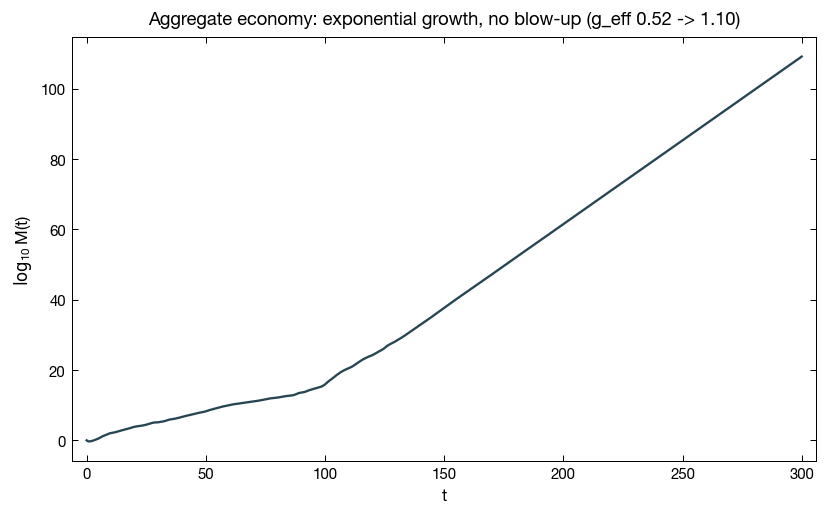

In [2]:
t, W, lnM = integrate(2024, 600, MU, SIGMA)
g1 = np.polyfit(t[t < 150], lnM[t < 150], 1)[0]; g2 = np.polyfit(t[t > 150], lnM[t > 150], 1)[0]
fig, ax = plt.subplots(figsize=(7, 4.4))
ax.plot(t, lnM / np.log(10), color="#264653")
ax.set(xlabel="t", ylabel=r"$\log_{10} M(t)$",
       title=f"Aggregate economy: exponential growth, no blow-up (g_eff {g1:.2f} -> {g2:.2f})")
plt.tight_layout(); plt.savefig("relative_glv_growth.png", dpi=120); plt.show()

## 2. The firm-growth "signal" is a relaxation transient

Measured in a short early window the shares look chaotic and yield plausible-looking MSB observables. But the
pooled growth volatility **decays toward zero** over long time: the shares **freeze to a fixed point**. The
apparent MSB tent was a transient, not a stationary property -- this is the trap a short window hides.

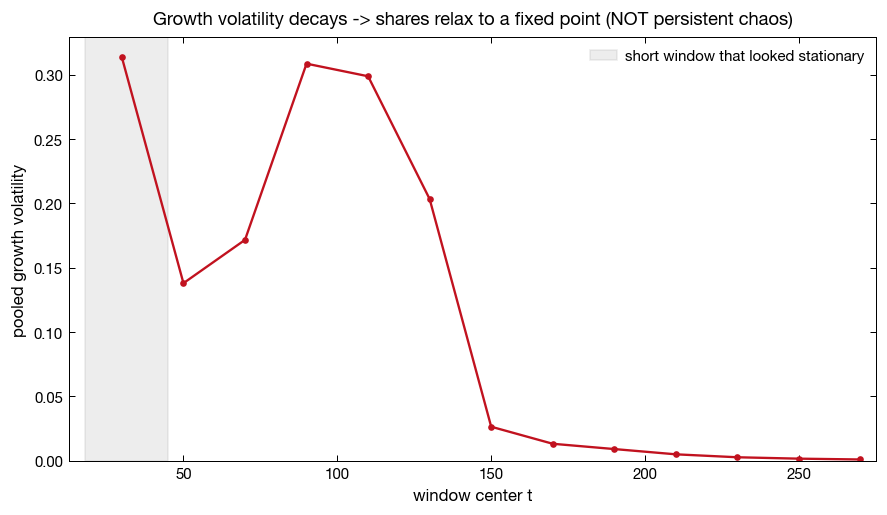

growth volatility: t~30 -> 0.314,  t~270 -> 0.0009  (decays to ~0)


In [3]:
wins = [(a, a + 20) for a in range(20, 280, 20)]
centers = [(a + b) / 2 for a, b in wins]
gstd = [window_growth(W, t, a, b)["gstd"] if window_growth(W, t, a, b) else np.nan for a, b in wins]
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot(centers, gstd, "o-", color="#c1121f")
ax.axvspan(18, 45, color="#888", alpha=0.15, label="short window that looked stationary")
ax.set(xlabel="window center t", ylabel="pooled growth volatility", ylim=(0, None),
       title="Growth volatility decays -> shares relax to a fixed point (NOT persistent chaos)")
ax.legend(); plt.tight_layout(); plt.savefig("relative_glv_relaxation.png", dpi=120); plt.show()
print(f"growth volatility: t~30 -> {gstd[0]:.3f},  t~270 -> {gstd[-1]:.4f}  (decays to ~0)")

## 3. Persistence is fragile, and where it survives the observables are wrong

Across independent realizations of a candidate regime, the late-window (stationary) growth volatility varies
enormously -- some seeds sustain chaos, most freeze. Where chaos *does* persist, the size-volatility decline is
a clean power law ($R^2$ good) but with $\beta\approx0.8$ (the empirical value is $\approx0.2$), and the growth
distribution, though symmetric (Bowley $\approx0$), is pathologically fat (excess kurtosis $\sim10^2$, not the
Laplace-like empirical tent).

Candidate regime mu=3 sigma=2 lam=1e-3, stationary window [200,280], 4 seeds:
  seed  late growth std  decline beta     R2   Bowley    exkurt


  8374            0.000          0.94   0.97    -0.20       658


  9467            0.223          0.63   0.88    -0.03        21


  5680            0.000          0.95   0.95    +0.10       251


  9757            0.251          0.65   0.87    -0.03         8


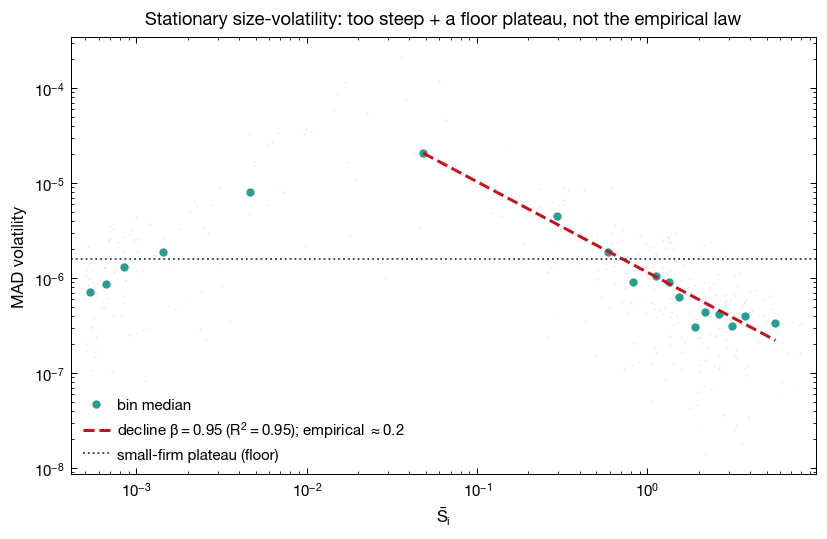

In [4]:
seeds = np.random.default_rng(123).integers(0, 2**31 - 1, size=4)
print(f"Candidate regime mu=3 sigma=2 lam=1e-3, stationary window [200,280], {len(seeds)} seeds:")
print(f"  {'seed':>4}  {'late growth std':>15}  {'decline beta':>12}  {'R2':>5}  {'Bowley':>7}  {'exkurt':>8}")
rows = []
for s in seeds:
    t2, W2, _ = integrate(int(s), 500, 3.0, 2.0, lam=1e-3)
    w = window_growth(W2, t2, 200, 280)
    if w is None:
        print(f"  {int(s)%10000:>4}  (condensed)"); continue
    beta, r2, _ = decline_beta(w["Sbar"], w["vol"])
    q1, q2, q3 = np.percentile(w["gl"], [25, 50, 75]); bow = (q3 + q1 - 2 * q2) / (q3 - q1)
    print(f"  {int(s)%10000:>4}  {w['gstd']:>15.3f}  {beta:>12.2f}  {r2:>5.2f}  {bow:>+7.2f}  {kurtosis(w['gl']):>8.0f}")
    rows.append((beta, r2, kurtosis(w["gl"]), w))

w = rows[int(np.argmax([r[0] for r in rows]))][3]      # a persistent seed: show its size-volatility shape
beta, r2, (bx, by, pk) = decline_beta(w["Sbar"], w["vol"])
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.loglog(w["Sbar"], w["vol"], ".", ms=2, alpha=0.2, color="gray")
ax.loglog(bx, by, "o", ms=5, color="#2a9d8f", label="bin median")
xx = np.logspace(np.log10(bx[pk]), np.log10(bx[-1]), 40)
ax.loglog(xx, by[pk] * (xx / bx[pk]) ** (-beta), "--", color="#c1121f", lw=1.8,
          label=fr"decline $\beta={beta:.2f}$ ($R^2={r2:.2f}$); empirical $\approx0.2$")
ax.axhline(np.median(by[:pk + 1]), color="#264653", ls=":", lw=1.1, label="small-firm plateau (floor)")
ax.set(xlabel=r"$\bar S_i$", ylabel="MAD volatility",
       title="Stationary size-volatility: too steep + a floor plateau, not the empirical law")
ax.legend(); plt.tight_layout(); plt.savefig("relative_glv_stationary.png", dpi=120); plt.show()

## Conclusion

Making the GLV interactions relative to the mean firm gives a clean, robust **growing-economy mechanism**:
the aggregate grows exponentially in unbounded physical time with no finite-time blow-up. That is the result
worth keeping.

It does **not**, however, reproduce the Moran-Bouchaud firm-growth stylized facts. An early short window looks
convincing, but the firm shares relax to a fixed point; persistent chaos survives only for some realizations
(fragile, as in the original model), and where it survives the stationary observables are quantitatively wrong
(size-volatility exponent $\approx0.8$ rather than $\approx0.2$; excess kurtosis $\sim10^2$). The apparent
match was a relaxation transient, exposed only by integrating long enough, checking stationarity across seeds,
and reporting $R^2$ on the power-law fit.